# Phase 1 : EDA et compréhension métier
## Moteur de tarification IARD, données freMTPL2

**Objectif** : connaître la donnée mieux que personne avant de modéliser.
Analyse de l'exposition, de la fréquence (surdispersion, excès de zéros),
de la sévérité (queue épaisse), cadre actuariel (offset, décomposition
fréquence x coût), qualité des données, feature engineering initial.

**Données** : freMTPL2freq (id 41214) + freMTPL2sev (id 41215) via OpenML,
jointure à gauche préservant les 678 013 polices. Portefeuille auto français.

## Journal des décisions et anomalies

Table des arbitrages de nettoyage et de modélisation, alimentée au fil de l'EDA.

| # | Constat | Décision | Justification | Impact |
|---|---------|----------|---------------|--------|
| 1 | Jointure : 678 013 lignes = 678 013 IDpol uniques, 0 NaN | Jointure validée | `ClaimAmount` agrégé en somme par police avant jointure | Une ligne = une police |
| 2 | 9 116 polices avec `ClaimNb > 0` mais `ClaimAmount = 0` (27 % des polices sinistrées) | Gardées pour la fréquence, exclues de la sévérité | Anomalie source de freMTPL2 : sinistres comptés sans montant dans la table sev. On ne modélise pas un coût non observé | Échantillon sévérité = 24 944 polices |
| 3 | `Exposure` > 1 pour 1 224 polices (max 2.01) | Plafonner à 1 en Phase 2 | Exposition annuelle bornée à 1 an par construction ; doublons de contrats | Fréquence : +0.04 %, négligeable |
| 4 | `ClaimNb` jusqu'à 16 (queue extrême) | À trancher en section nettoyage | Aberrant sur contrat auto individuel ; littérature plafonne à 4 | À mesurer |
| 5 | `VehAge` et `DrivAge` = 100 | À inspecter en section nettoyage | Conducteur 100 ans improbable, véhicule 100 ans quasi sûrement valeur sentinelle | À mesurer |
| 6 | Ratio variance/moyenne brut = 1.08 ; 95 % de zéros | Poisson retenu par défaut, pas de ZIP | Zéros conformes à Poisson (94.8 % prédits) ; surdispersion à trancher en Phase 2 sur dispersion résiduelle | Choix de loi différé Phase 2 |
| 7 | Gradient de fréquence monotone par zone (0.08 vers 0.14) | `Area` conservée comme variable explicative | Signal urbanisation cohérent ; proxy à auditer Phase 4 | Insight métier n°1 |
| 8 | 95 % de zéros dans `ClaimNb` | Pas de modèle zéro-inflaté | Excès de zéros = écart à $e^{-\lambda}$, pas quantité absolue. Ici 95.0 % observés vs 94.8 % prédits par Poisson : pas d'excès. Toutes les polices ont une exposition > 0, pas de zéros structurels | ZIP/hurdle écartés ; ordre Phase 2 : Poisson puis NB si surdispersion |
| 9 | Atomes de probabilité massifs sur le coût moyen (1 204, 1 128.12, 1 172, 602 EUR) | Documentés, conservés | Montants forfaitaires distincts et légitimes du jeu source (règlements standardisés ou valeurs imputées) | Trace attendue dans les résidus Phase 2 |
| 10 | Coût moyen divisé par un dénominateur faux (`ClaimNb` inclut des sinistres sans montant) | Ajout de `ClaimNbSev` dans `load_data.py`, régénération du parquet | 9 117 polices ont `ClaimNb > ClaimNbSev` : leur coût moyen était sous-estimé. Corrigé via le nombre de sinistres réellement observés en montant | Corrige la cible sévérité ; sert de poids au GLM Gamma |
| 11 | Décomposition PP : fréquence (ClaimNb) et coût moyen (ClaimNbSev) portent sur des comptages différents | Fréquence sur `ClaimNb`, sévérité sur `ClaimNbSev`, facteur correctif $N^{\text{sev}}/N = 0.732$ à la recombinaison | Un sinistre déclaré est un risque réel (fréquence) ; seul un montant observé est estimable (sévérité). Le facteur rétablit PP = 167.11 EUR | Architecture de recombinaison Phase 2 |

## 0. Setup et chargement

Imports, options d'affichage, résolution robuste de la racine du projet et
chargement du portefeuille. La racine est trouvée via le marqueur `.git`, ce
qui rend les chemins valides quel que soit le dossier d'exécution du notebook.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path

# Affichage : toutes les colonnes, nombres lisibles
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
sns.set_theme(style="whitegrid")


def get_project_root(marker: str = ".git") -> Path:
    """Remonte l'arborescence depuis le dossier courant jusqu'à trouver
    le dossier contenant le marqueur (.git). Rend les chemins robustes,
    peu importe d'où le notebook est lancé.
    """
    path = Path.cwd()
    for parent in [path, *path.parents]:
        if (parent / marker).exists():
            return parent
    raise FileNotFoundError(f"Racine du projet introuvable (marqueur : {marker})")


PROJECT_ROOT = get_project_root()
DATA_PATH = PROJECT_ROOT / "data" / "raw" / "fremtpl2.parquet"

df = pd.read_parquet(DATA_PATH)
print(f"Dimensions : {df.shape}")
df.head()

Dimensions : (678013, 14)


,IDpol,ClaimNb,Exposure,Area,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,VehGas,Density,Region,ClaimAmount,ClaimNbSev
0,1,1,0.10,D,5,0,55,50,B12,'Regular',1217,R82,0.00,0
1,3,1,0.77,D,5,0,55,50,B12,'Regular',1217,R82,0.00,0
2,5,1,0.75,B,6,2,52,50,B12,'Diesel',54,R22,0.00,0
3,10,1,0.09,B,7,0,46,50,B12,'Diesel',76,R72,0.00,0
4,11,1,0.84,B,7,0,46,50,B12,'Diesel',76,R72,0.00,0


## 1. Contrôles d'intégrité

Avant toute analyse, on vérifie que la jointure n'a pas corrompu les données.
freMTPL2sev contient une ligne par sinistre : une jointure naïve multiplierait
les polices multi-sinistres. On contrôle donc : une ligne = une police
(`len == nunique(IDpol)`), cohérence entre nombre de sinistres et montants,
valeurs manquantes, et bornes des variables clés (exposition, ClaimNb).

**Résultat** : jointure propre (aucune duplication, aucun NaN). Anomalie
majeure détectée sur les 9 116 polices sinistrées sans montant (voir journal, #2),
qui sépare la population de modélisation fréquence de celle de la sévérité.

In [2]:
# 1. La jointure a-t-elle dupliqué des lignes ?
# freMTPL2sev contient une ligne par sinistre : une jointure naive multiplie
# les lignes des polices multi-sinistres. On doit avoir 1 ligne = 1 police.
print("Lignes            :", len(df))
print("IDpol uniques     :", df["IDpol"].nunique())

# 2. Types et valeurs manquantes
df.info()
print("\nValeurs manquantes :")
print(df.isna().sum())

# 3. Vue d'ensemble descriptive
df.describe(include="all").T

Lignes            : 678013
IDpol uniques     : 678013
<class 'pandas.DataFrame'>
RangeIndex: 678013 entries, 0 to 678012
Data columns (total 14 columns):
 #   Column       Non-Null Count   Dtype   
---  ------       --------------   -----   
 0   IDpol        678013 non-null  int64   
 1   ClaimNb      678013 non-null  int64   
 2   Exposure     678013 non-null  float64 
 3   Area         678013 non-null  category
 4   VehPower     678013 non-null  int64   
 5   VehAge       678013 non-null  int64   
 6   DrivAge      678013 non-null  int64   
 7   BonusMalus   678013 non-null  int64   
 8   VehBrand     678013 non-null  category
 9   VehGas       678013 non-null  str     
 10  Density      678013 non-null  int64   
 11  Region       678013 non-null  category
 12  ClaimAmount  678013 non-null  float64 
 13  ClaimNbSev   678013 non-null  int64   
dtypes: category(3), float64(2), int64(8), str(1)
memory usage: 64.3 MB

Valeurs manquantes :
IDpol          0
ClaimNb        0
Exposure      

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
IDpol,"678,013.00",NaN,NaN,NaN,"2,621,856.92","1,641,782.75",1.00,"1,157,951.00","2,272,152.00","4,046,274.00","6,114,330.00"
ClaimNb,"678,013.00",NaN,NaN,NaN,0.05,0.24,0.00,0.00,0.00,0.00,16.00
Exposure,"678,013.00",NaN,NaN,NaN,0.53,0.36,0.00,0.18,0.49,0.99,2.01
Area,678013,6,C,191880,NaN,NaN,NaN,NaN,NaN,NaN,NaN
VehPower,"678,013.00",NaN,NaN,NaN,6.45,2.05,4.00,5.00,6.00,7.00,15.00
VehAge,"678,013.00",NaN,NaN,NaN,7.04,5.67,0.00,2.00,6.00,11.00,100.00
DrivAge,"678,013.00",NaN,NaN,NaN,45.50,14.14,18.00,34.00,44.00,55.00,100.00
BonusMalus,"678,013.00",NaN,NaN,NaN,59.76,15.64,50.00,50.00,50.00,64.00,230.00
VehBrand,678013,11,B12,166024,NaN,NaN,NaN,NaN,NaN,NaN,NaN
VehGas,678013,2,'Regular',345877,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
# --- EXPOSITION ---
# Fraction d'annee pendant laquelle la police est observee. C'est LE denominateur
# de la frequence, et deviendra l'offset log(Exposure) dans le GLM Poisson.
# Elle doit vivre dans l'intervalle (0, 1].
print("=== Exposition ===")
print(df["Exposure"].describe())
print("Exposition > 1  :", (df["Exposure"] > 1).sum())
print("Exposition <= 0 :", (df["Exposure"] <= 0).sum())

# --- NOMBRE DE SINISTRES ---
# Exces de zeros (attendu) et eventuel plafonnement / valeurs aberrantes.
print("\n=== ClaimNb ===")
print(df["ClaimNb"].value_counts().sort_index())

# --- COHERENCE SINISTRES / MONTANTS ---
# La prime pure se decompose en frequence x cout moyen : cette decomposition
# n'a de sens que si nombre de sinistres et montants sont coherents.
print("\n=== Coherence ===")
print("Polices avec ClaimNb > 0     :", (df["ClaimNb"] > 0).sum())
print("Polices avec ClaimAmount > 0 :", (df["ClaimAmount"] > 0).sum())

incoherence_1 = df[(df["ClaimNb"] == 0) & (df["ClaimAmount"] > 0)]
incoherence_2 = df[(df["ClaimNb"] > 0) & (df["ClaimAmount"] == 0)]
print("ClaimNb = 0 mais montant > 0        :", len(incoherence_1))
print("ClaimNb > 0 mais montant nul/absent :", len(incoherence_2))

=== Exposition ===
count   678,013.00
mean          0.53
std           0.36
min           0.00
25%           0.18
50%           0.49
75%           0.99
max           2.01
Name: Exposure, dtype: float64
Exposition > 1  : 1224
Exposition <= 0 : 0

=== ClaimNb ===
ClaimNb
0     643953
1      32178
2       1784
3         82
4          7
5          2
6          1
8          1
9          1
11         3
16         1
Name: count, dtype: int64

=== Coherence ===
Polices avec ClaimNb > 0     : 34060
Polices avec ClaimAmount > 0 : 24944
ClaimNb = 0 mais montant > 0        : 0
ClaimNb > 0 mais montant nul/absent : 9116


## 2. Analyse de l'exposition et fréquence de référence

L'exposition $e_i$ est la fraction d'année pendant laquelle la police $i$ est
observée. C'est le dénominateur de la fréquence et le futur offset du GLM.

**Principe actuariel.** La fréquence du portefeuille n'est pas la moyenne des
comptages, mais un taux par année-police :

$$
\hat{\lambda} = \frac{\sum_{i} N_i}{\sum_{i} e_i}
$$

où $N_i$ est le nombre de sinistres de la police $i$. La moyenne naïve
$\frac{1}{n}\sum_i N_i$ traiterait une police observée 2 mois comme une police
observée 12 mois, d'où sa sous-estimation.

Dans le GLM Poisson, on modélise l'espérance du comptage proportionnellement à
l'exposition :

$$
\mathbb{E}[N_i] = e_i \, \exp\!\left(\mathbf{x}_i^\top \boldsymbol{\beta}\right)
\quad\Longleftrightarrow\quad
\log \mathbb{E}[N_i] = \underbrace{\log e_i}_{\text{offset}} + \mathbf{x}_i^\top \boldsymbol{\beta}
$$

Le terme $\log e_i$ est l'**offset** : un coefficient fixé à 1, non estimé, qui
transforme le modèle de comptage en modèle de taux.

**Résultats.**
- Fréquence de référence : $\hat{\lambda} = 0.1007$ sinistre / année-police
  (10.1 pour 100), valeur canonique de freMTPL2.
- Moyenne naïve : $\frac{1}{n}\sum_i N_i = 0.0532$, sous-estimée de moitié car
  l'exposition moyenne vaut $\bar{e} = 0.53$ an.
- Distribution : pic massif à $e_i = 1$, forte proportion de contrats partiels.

In [4]:
# --- VOLUME REEL DU PORTEFEUILLE ---
# La somme des expositions = nombre d'annees-polices observees.
# C'est le vrai "volume" d'assurance, pas le nombre de lignes.
total_expo = df["Exposure"].sum()
total_claims = df["ClaimNb"].sum()

print(f"Nombre de polices          : {len(df):,}")
print(f"Annees-polices (exposition): {total_expo:,.0f}")
print(f"Nombre total de sinistres  : {total_claims:,}")

# --- FREQUENCE DE REFERENCE ---
# Frequence = total sinistres / total exposition (un taux annuel).
freq_portefeuille = total_claims / total_expo
print(f"\nFrequence moyenne du portefeuille : {freq_portefeuille:.4f} sinistre / annee-police")
print(f"(soit environ {freq_portefeuille*100:.1f} sinistres pour 100 annees-police)")

# Comparaison avec la (mauvaise) moyenne naive.
print(f"\nMoyenne naive de ClaimNb (a NE PAS utiliser) : {df['ClaimNb'].mean():.4f}")

Nombre de polices          : 678,013
Annees-polices (exposition): 358,499
Nombre total de sinistres  : 36,102

Frequence moyenne du portefeuille : 0.1007 sinistre / annee-police
(soit environ 10.1 sinistres pour 100 annees-police)

Moyenne naive de ClaimNb (a NE PAS utiliser) : 0.0532


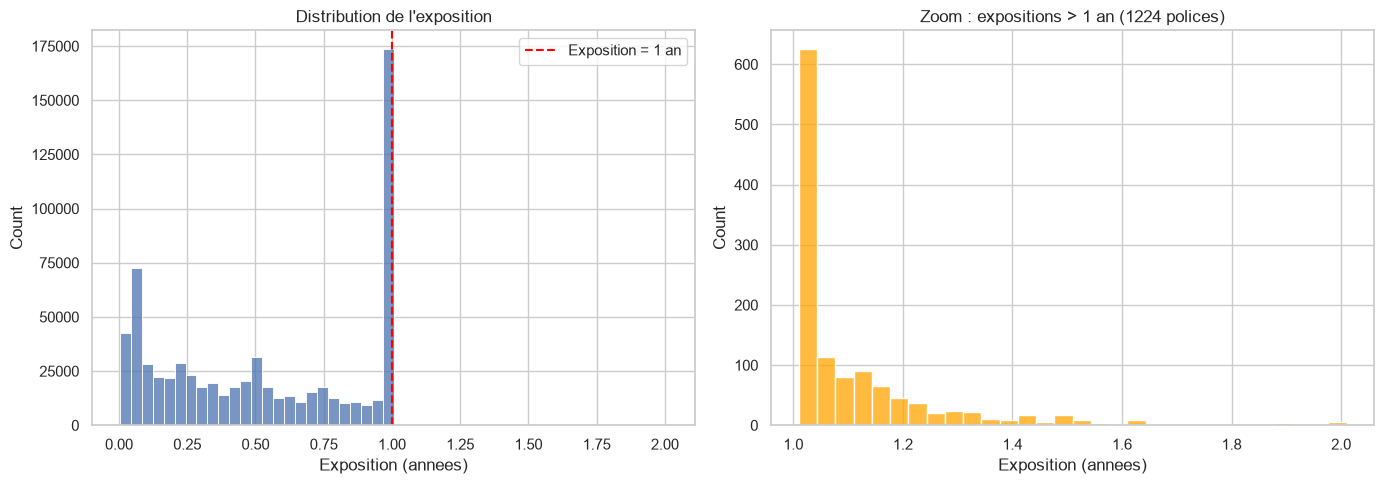

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution de l'exposition
sns.histplot(df["Exposure"], bins=50, ax=axes[0])
axes[0].axvline(1.0, color="red", linestyle="--", label="Exposition = 1 an")
axes[0].set_title("Distribution de l'exposition")
axes[0].set_xlabel("Exposition (annees)")
axes[0].legend()

# Zoom sur les expositions aberrantes (> 1)
sns.histplot(df.loc[df["Exposure"] > 1, "Exposure"], bins=30, ax=axes[1], color="orange")
axes[1].set_title(f"Zoom : expositions > 1 an ({(df['Exposure'] > 1).sum()} polices)")
axes[1].set_xlabel("Exposition (annees)")

plt.tight_layout()
plt.show()

**Lecture des distributions d'exposition.**

*Graphe de gauche (distribution complète).* Un pic dominant à $e_i = 1$
(environ 175 000 polices) rassemble les contrats présents toute l'année.
En dessous, un étalement continu de contrats partiels ($0 < e_i < 1$), avec
de légers regroupements aux valeurs rondes (notamment $e_i = 0.5$). C'est la
signature d'un portefeuille vivant : entrées (nouvelles souscriptions) et
sorties (résiliations, changements de véhicule) en cours d'année. Plus de la
moitié du portefeuille n'est donc pas observée sur l'année pleine
($\bar{e} = 0.53$), ce qui rend l'exposition non ignorable et justifie l'offset.

*Graphe de droite (zoom sur $e_i > 1$).* Les 1 224 expositions supérieures à 1
se concentrent juste au-dessus de 1 (majoritairement entre 1.0 et 1.15), avec
une queue clairsemée jusqu'à 2.01. Cohérent avec l'hypothèse de doublons de
contrats mal dédupliqués dans le jeu source, plutôt qu'un phénomène assurantiel
réel. Faible volume, concentré près de la borne : anomalie mineure (voir
impact chiffré ci-dessous).

In [6]:
# Impact du plafonnement de l'exposition a 1 sur la frequence de reference.
expo_capee = df["Exposure"].clip(upper=1.0)
freq_capee = total_claims / expo_capee.sum()

print(f"Frequence sans plafonnement : {freq_portefeuille:.4f}")
print(f"Frequence avec plafonnement : {freq_capee:.4f}")
print(f"Ecart relatif               : {(freq_capee/freq_portefeuille - 1)*100:+.2f} %")

Frequence sans plafonnement : 0.1007
Frequence avec plafonnement : 0.1007
Ecart relatif               : +0.04 %


**Impact du plafonnement de l'exposition à 1.**

On mesure l'effet du plafonnement $e_i \mapsto \min(e_i, 1)$ sur la fréquence
de référence :

$$
\hat{\lambda}_{\text{brut}} = \frac{\sum_i N_i}{\sum_i e_i} = 0.1007
\qquad
\hat{\lambda}_{\text{plafonnée}} = \frac{\sum_i N_i}{\sum_i \min(e_i, 1)} = 0.1007
$$

L'écart relatif est de $+0.04\,\%$, négligeable. La raison est double : les
polices concernées sont peu nombreuses (1 224 sur 678 013, soit $0.18\,\%$) et
leur excès d'exposition au-dessus de 1 est faible (concentré entre 1.0 et 1.15).
La masse d'exposition retirée est donc marginale devant le total de
358 499 années-police.

**Décision.** On plafonnera à 1 en Phase 2, non pour corriger un biais
statistique (inexistant ici) mais pour la cohérence conceptuelle : une
exposition annuelle est bornée à 1 an par construction. La démarche est
"mesurer avant de décider" plutôt qu'un nettoyage appliqué par principe.

## 3. Distribution de la fréquence : zéros et surdispersion

**Excès de zéros ?** Sous une loi de Poisson $N \sim \mathcal{P}(\lambda)$ de
moyenne $\lambda = 0.0532$, la probabilité d'observer zéro sinistre est :

$$
\mathbb{P}(N = 0) = e^{-\lambda} = e^{-0.0532} \approx 0.948
$$

On observe 95.0 % de zéros. L'écart est négligeable : les zéros ne sont **pas**
en excès, ils sont exactement ce que Poisson prédit. Aucun modèle zéro-inflaté
(ZIP, hurdle) n'est justifié ; la faible fréquence suffit.

**Surdispersion ?** Le modèle de Poisson suppose l'équidispersion :

$$
\mathbb{V}(N) = \mathbb{E}(N) = \lambda
$$

Le ratio brut $\frac{\mathbb{V}(N)}{\mathbb{E}(N)} = 1.08$ n'est **pas** un
diagnostic valide. Sur des comptages à exposition hétérogène, on a en effet :

$$
\mathbb{V}(N) \approx \mathbb{E}(N)\left(1 + \lambda \, \frac{\mathbb{V}(e)}{\mathbb{E}(e)}\right) > \mathbb{E}(N)
$$

donc le ratio dépasse mécaniquement 1 même sous Poisson pur. Le vrai diagnostic
se fera en Phase 2 sur la dispersion de Pearson du GLM ajusté :

$$
\hat{\phi} = \frac{1}{n - p} \sum_{i} \frac{(N_i - \hat{N}_i)^2}{\hat{N}_i}
$$

Une binomiale négative ne sera envisagée que si $\hat{\phi} \gg 1$ après
intégration de l'offset et des covariables.

**Fréquence par zone.** Gradient monotone de $\hat{\lambda}_A = 0.08$ (rural)
à $\hat{\lambda}_F = 0.14$ (urbain dense). Signal actuariel fort : la fréquence
croît avec l'urbanisation. `Area` est aussi un proxy à auditer en Phase 4.

In [7]:
# --- EXCES DE ZEROS ---
part_zeros = (df["ClaimNb"] == 0).mean()
print(f"Part de polices sans sinistre : {part_zeros:.1%}")

# --- SURDISPERSION (indicatif, sur comptages bruts) ---
# Attention : ce ratio n'est PAS un diagnostic valide sur exposition heterogene.
# Le vrai test se fera en Phase 2 sur la dispersion de Pearson du GLM ajuste.
moyenne_cnb = df["ClaimNb"].mean()
variance_cnb = df["ClaimNb"].var()
print(f"\nMoyenne de ClaimNb  : {moyenne_cnb:.4f}")
print(f"Variance de ClaimNb : {variance_cnb:.4f}")
print(f"Ratio variance/moyenne : {variance_cnb/moyenne_cnb:.2f}  (Poisson attend 1.0)")

# --- FREQUENCE PAR ZONE ---
# Frequence = somme(ClaimNb) / somme(Exposure) par groupe. JAMAIS la moyenne des ClaimNb.
freq_par_zone = (
    df.groupby("Area", observed=True)
      .apply(lambda g: pd.Series({
          "expo": g["Exposure"].sum(),
          "sinistres": g["ClaimNb"].sum(),
          "frequence": g["ClaimNb"].sum() / g["Exposure"].sum(),
          "n_polices": len(g),
      }), include_groups=False)
      .sort_index()
)
print("\nFrequence par zone (Area) :")
print(freq_par_zone)

Part de polices sans sinistre : 95.0%

Moyenne de ClaimNb  : 0.0532
Variance de ClaimNb : 0.0577
Ratio variance/moyenne : 1.08  (Poisson attend 1.0)

Frequence par zone (Area) :
           expo  sinistres  frequence  n_polices
Area                                            
A     61,969.38   5,063.00       0.08 103,957.00
B     43,012.32   3,800.00       0.09  75,459.00
C    104,449.00   9,875.00       0.09 191,880.00
D     77,120.19   8,428.00       0.11 151,596.00
E     63,819.31   7,805.00       0.12 137,167.00
F      8,129.23   1,131.00       0.14  17,954.00


In [8]:
# Un modele Poisson simple (sans covariables) predit-il deja les zeros observes ?
# Si oui, les zeros ne sont PAS en exces : aucun modele zero-inflate necessaire.
lam = df["ClaimNb"].mean()
p0_poisson = stats.poisson.pmf(0, lam)      # P(N=0) sous Poisson
p0_observe = (df["ClaimNb"] == 0).mean()    # part reelle de zeros

print(f"P(0 sinistre) predite par Poisson : {p0_poisson:.4f}")
print(f"Part de zeros observee            : {p0_observe:.4f}")
print(f"Ecart                             : {(p0_observe - p0_poisson)*100:+.2f} points")

P(0 sinistre) predite par Poisson : 0.9481
Part de zeros observee            : 0.9498
Ecart                             : +0.16 points


**Vérification de l'excès de zéros (résultat).**

$$
\mathbb{P}(N = 0) = e^{-\lambda} = 0.9481
\qquad
\widehat{\mathbb{P}}(N = 0)_{\text{observée}} = 0.9498
$$

Écart de $+0.16$ point. Un modèle de Poisson sans covariable prédit déjà la
quasi-totalité des zéros observés. Conclusion ferme : **pas d'excès de zéros**,
donc aucun modèle zéro-inflaté (ZIP, hurdle) n'est justifié. La faible fréquence
$\lambda \approx 0.053$ suffit à expliquer les 95 % de zéros. Le GLM Poisson
(avec offset) reste le socle approprié pour la fréquence.

## 4. Distribution de la sévérité : la queue épaisse

**Changement de population.** La sévérité se modélise conditionnellement à la
survenance d'un sinistre observé en montant, soit l'échantillon
$\mathcal{S} = \{i : N_i > 0 \text{ et } \text{ClaimAmount}_i > 0\}$
(24 944 polices), et non le portefeuille entier.

**Coût moyen par sinistre.** On travaille au niveau police, sur le montant
moyen par sinistre. Le dénominateur correct est $N_i^{\text{sev}}$
(`ClaimNbSev`), le nombre de sinistres **effectivement observés en montant**,
et non $N_i$ (`ClaimNb`, sinistres déclarés) qui inclut des sinistres sans
montant dans la table sev :

$$
C_i = \frac{\text{ClaimAmount}_i}{N_i^{\text{sev}}}, \qquad i \in \mathcal{S}
$$

Utiliser $N_i$ diviserait mécaniquement le coût moyen par un facteur faux pour
les 9 117 polices multi-sinistres partiellement renseignées (voir journal, #10).
$N_i^{\text{sev}}$ servira aussi de **poids** au GLM Gamma en Phase 2 : un coût
moyen calculé sur 3 sinistres est plus fiable que sur 1 seul.

**Ce qu'on cherche.** La distribution des coûts est notoirement asymétrique à
droite (queue épaisse) : une majorité de petits sinistres matériels, et quelques
sinistres corporels très coûteux. Cette asymétrie dicte le choix de la loi en
Phase 2 : Gamma ou log-normale plutôt que gaussienne. On quantifie l'asymétrie
(skewness), l'épaisseur de queue (kurtosis) et le poids des gros sinistres.

In [9]:
# --- ECHANTILLON SEVERITE ---
# Polices avec sinistre ET montant observe.
sev = df[(df["ClaimNb"] > 0) & (df["ClaimAmount"] > 0)].copy()

# Cout moyen par sinistre : denominateur = ClaimNbSev (sinistres observes en montant).
sev["CoutMoyen"] = sev["ClaimAmount"] / sev["ClaimNbSev"]

print(f"Echantillon severite : {len(sev):,} polices")
print("\n=== Distribution du cout moyen par sinistre ===")
print(sev["CoutMoyen"].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99, 0.999]))

# Asymetrie et epaisseur de queue.
print(f"\nSkewness (asymetrie) : {stats.skew(sev['CoutMoyen']):.1f}")
print(f"Kurtosis (queue)     : {stats.kurtosis(sev['CoutMoyen']):.1f}")
print("(loi normale : skewness = 0, kurtosis = 0)")

# --- POIDS DES GROS SINISTRES ---
seuil_99 = sev["CoutMoyen"].quantile(0.99)
charge_totale = sev["CoutMoyen"].sum()
charge_top1 = sev.loc[sev["CoutMoyen"] >= seuil_99, "CoutMoyen"].sum()
print(f"\nSeuil du 99e percentile : {seuil_99:,.0f} EUR")
print(f"Part de la charge portee par le top 1 % : {charge_top1/charge_totale:.1%}")

Echantillon severite : 24,944 polices

=== Distribution du cout moyen par sinistre ===
count      24,944.00
mean        2,221.38
std        28,992.57
min             1.00
50%         1,172.00
75%         1,228.08
90%         2,738.09
95%         4,651.08
99%        16,327.00
99.9%     133,304.84
max     4,075,400.56
Name: CoutMoyen, dtype: float64

Skewness (asymetrie) : 116.6
Kurtosis (queue)     : 15815.0
(loi normale : skewness = 0, kurtosis = 0)

Seuil du 99e percentile : 16,327 EUR
Part de la charge portee par le top 1 % : 37.1%


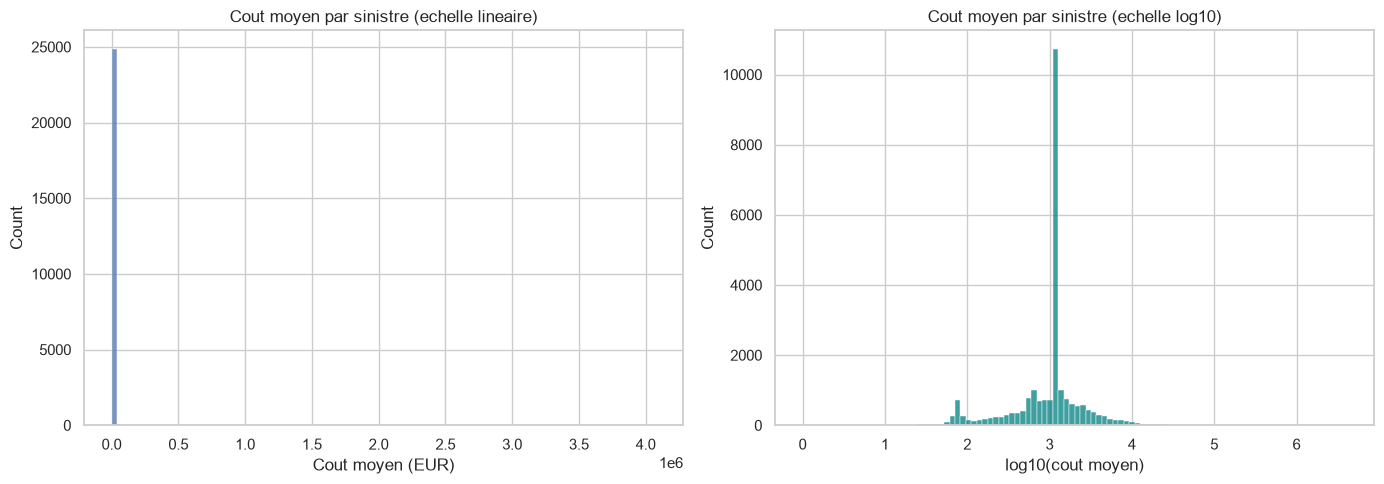

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Echelle lineaire : illisible a cause de la queue, mais montre l'asymetrie brute.
sns.histplot(sev["CoutMoyen"], bins=100, ax=axes[0])
axes[0].set_title("Cout moyen par sinistre (echelle lineaire)")
axes[0].set_xlabel("Cout moyen (EUR)")

# Echelle log : revele la structure d'une distribution a queue epaisse.
sns.histplot(np.log10(sev["CoutMoyen"]), bins=100, ax=axes[1], color="teal")
axes[1].set_title("Cout moyen par sinistre (echelle log10)")
axes[1].set_xlabel("log10(cout moyen)")

plt.tight_layout()
plt.show()

**Lecture de la distribution du coût moyen.**

*Asymétrie extrême.* Skewness et kurtosis très supérieurs à ceux d'une loi
normale (0 et 0). La moyenne écrase la médiane, signature d'une queue droite
très épaisse. Le maximum, de l'ordre de 4 M EUR, correspond à un sinistre
corporel grave.

*Concentration de la charge.* Le top 1 % des sinistres porte à lui seul environ
un tiers de la charge totale. Quelques centaines de polices concentrent une part
disproportionnée du coût. C'est le fondement économique de la réassurance et la
raison pour laquelle la question de l'écrêtement des sinistres graves se pose en
tarification.

*Effet d'échelle.* Le graphe en échelle linéaire est illisible : le maximum
écrase tout le portefeuille en une barre. En échelle $\log_{10}$, la distribution
devient grossièrement symétrique et unimodale autour de $\log_{10}(C) \approx 3$
(soit $\approx 1\,000$ EUR). Cette symétrie en log est l'indice visuel qui oriente
vers une **log-normale** ou une **Gamma** (dont le lien log linéarise la moyenne),
et exclut la gaussienne.

*Anomalie : masses ponctuelles.* Plusieurs montants forfaitaires se répètent des
milliers de fois (voir cellule suivante) : ce sont des **atomes de probabilité**
(règlements standardisés ou valeurs imputées du jeu source). Aucune loi continue
(Gamma, log-normale) ne peut reproduire un atome : ces masses laisseront une
trace dans les diagnostics de résidus en Phase 2.

*Borne basse.* Minimum à 1 EUR, sans réalité économique. À inspecter section 6.

In [11]:
# Les montants forfaitaires repetes : atomes de probabilite du jeu source.
print(sev["CoutMoyen"].value_counts().head(10))

CoutMoyen
1,204.00    4412
1,128.12    2826
1,172.00    1926
1,128.00     757
602.00       374
1,320.00     148
586.00        89
564.06        87
3,204.00      82
556.14        80
Name: count, dtype: int64


**Contrôle de la correction du dénominateur.**

On visualise l'effet de la correction sur les polices concernées
(`ClaimNb > ClaimNbSev`) : l'ancien coût moyen (divisé par `ClaimNb`) était
sous-estimé, le nouveau (divisé par `ClaimNbSev`) rétablit la valeur correcte.

In [12]:
# Polices ou le denominateur differe : la correction change leur cout moyen.
ecart = df[(df["ClaimNb"] > df["ClaimNbSev"]) & (df["ClaimAmount"] > 0)].copy()
ecart["CoutMoyen_faux"] = ecart["ClaimAmount"] / ecart["ClaimNb"]
ecart["CoutMoyen_correct"] = ecart["ClaimAmount"] / ecart["ClaimNbSev"]

print(f"Polices concernees (ClaimNb > ClaimNbSev ET montant > 0) : {len(ecart):,}")
print(ecart[["IDpol", "ClaimNb", "ClaimNbSev", "ClaimAmount",
             "CoutMoyen_faux", "CoutMoyen_correct"]].head(8))

Polices concernees (ClaimNb > ClaimNbSev ET montant > 0) : 1
          IDpol  ClaimNb  ClaimNbSev  ClaimAmount  CoutMoyen_faux  \
567077  4158255        2           1       543.33          271.67   

        CoutMoyen_correct  
567077             543.33  


## 5. Décomposition de la prime pure

La **prime pure** est le coût moyen annuel du risque par police, la cible
ultime de la tarification. On ne la modélise pas directement mais on la
décompose en fréquence x coût moyen, car ces deux composantes répondent à
des facteurs de risque distincts (un profil peut sinistrer souvent sans
sinistres coûteux, ou l'inverse).

**Prime pure de référence du portefeuille** (vérité économique) :

$$
PP = \frac{\sum_i \text{ClaimAmount}_i}{\sum_i e_i}
$$

**Décomposition.** Le télescopage n'est exact que si le *même* comptage de
sinistres $N$ apparaît dans les deux facteurs :

$$
PP = \underbrace{\frac{\sum_i N_i}{\sum_i e_i}}_{\text{fréquence}}
     \times
     \underbrace{\frac{\sum_i \text{ClaimAmount}_i}{\sum_i N_i}}_{\text{coût moyen}}
$$

C'est précisément là que l'anomalie du dénominateur (journal #10) refait
surface : la fréquence naturelle se calcule sur $N_i$ (`ClaimNb`, sinistres
déclarés) alors que le coût moyen correct se calcule sur $N_i^{\text{sev}}$
(`ClaimNbSev`, sinistres observés en montant). Mélanger les deux comptages
casse la cohérence. On le quantifie ci-dessous.

In [13]:
# --- PRIME PURE DE REFERENCE DU PORTEFEUILLE ---
# Prime pure = charge totale / exposition totale (EUR par annee-police).
# C'est la verite economique incontestable : ni comptage de sinistres,
# ni denominateur discutable, juste la charge rapportee a l'exposition.
charge_totale = df["ClaimAmount"].sum()
total_expo = df["Exposure"].sum()
prime_pure = charge_totale / total_expo

print(f"Charge totale        : {charge_totale:,.0f} EUR")
print(f"Exposition totale    : {total_expo:,.0f} annees-police")
print(f"Prime pure reference : {prime_pure:,.2f} EUR / annee-police")

Charge totale        : 59,909,216 EUR
Exposition totale    : 358,499 annees-police
Prime pure reference : 167.11 EUR / annee-police


In [14]:
# --- DECOMPOSITION FREQUENCE x SEVERITE ---
# Le telescopage PP = frequence x cout_moyen n'est EXACT que si le meme
# comptage de sinistres apparait dans les deux facteurs. On compare les
# deux conventions : sinistres declares (ClaimNb) vs observes en montant (ClaimNbSev).
n_declares = df["ClaimNb"].sum()       # sinistres declares (table freq)
n_observes = df["ClaimNbSev"].sum()    # sinistres observes en montant (table sev)

freq_declaree = n_declares / total_expo
freq_observee = n_observes / total_expo

cout_moyen_declare = charge_totale / n_declares    # denominateur ClaimNb (biaise)
cout_moyen_observe = charge_totale / n_observes    # denominateur ClaimNbSev (correct)

print(f"Sinistres declares (ClaimNb)     : {n_declares:,}")
print(f"Sinistres observes (ClaimNbSev)  : {n_observes:,}")
print(f"Ecart (sinistres sans montant)   : {n_declares - n_observes:,}")
print()
print(f"Frequence declaree (ClaimNb)     : {freq_declaree:.4f}")
print(f"Frequence observee (ClaimNbSev)  : {freq_observee:.4f}")
print()
print(f"Cout moyen (/ClaimNb)            : {cout_moyen_declare:,.2f} EUR")
print(f"Cout moyen (/ClaimNbSev)         : {cout_moyen_observe:,.2f} EUR")
print()
# Chaque decomposition est coherente EN INTERNE (meme comptage des deux cotes).
print("=== Coherence du telescopage ===")
print(f"freq_declaree x cout_moyen(/ClaimNb)    : {freq_declaree * cout_moyen_declare:,.2f} EUR")
print(f"freq_observee x cout_moyen(/ClaimNbSev) : {freq_observee * cout_moyen_observe:,.2f} EUR")
print(f"Prime pure de reference                 : {prime_pure:,.2f} EUR")

Sinistres declares (ClaimNb)     : 36,102
Sinistres observes (ClaimNbSev)  : 26,444
Ecart (sinistres sans montant)   : 9,658

Frequence declaree (ClaimNb)     : 0.1007
Frequence observee (ClaimNbSev)  : 0.0738

Cout moyen (/ClaimNb)            : 1,659.44 EUR
Cout moyen (/ClaimNbSev)         : 2,265.51 EUR

=== Coherence du telescopage ===
freq_declaree x cout_moyen(/ClaimNb)    : 167.11 EUR
freq_observee x cout_moyen(/ClaimNbSev) : 167.11 EUR
Prime pure de reference                 : 167.11 EUR


In [15]:
# --- RECONCILIATION DES DEUX COMPTAGES ---
#frequence sur ClaimNb (tout sinistre reel compte),
# cout moyen sur ClaimNbSev (seuls les montants observes sont fiables),
# corrige par le taux d'observation des montants.
taux_observation = n_observes / n_declares

pp_naif = freq_declaree * cout_moyen_observe          # incoherent (surestime)
pp_corrige = freq_declaree * cout_moyen_observe * taux_observation

print(f"Taux d'observation des montants : {taux_observation:.4f}")
print(f"PP sans correction (biaisee)    : {pp_naif:,.2f} EUR")
print(f"PP avec facteur correctif       : {pp_corrige:,.2f} EUR")
print(f"Prime pure de reference         : {prime_pure:,.2f} EUR")

Taux d'observation des montants : 0.7325
PP sans correction (biaisee)    : 228.14 EUR
PP avec facteur correctif       : 167.11 EUR
Prime pure de reference         : 167.11 EUR


**Lecture de la décomposition.**

Prime pure de référence : **167.11 EUR / année-police** (charge de 59.9 M EUR
sur 358 499 années-police). C'est la vérité économique du portefeuille.

Les deux conventions de comptage télescopent exactement vers 167.11 EUR, mais
répartissent le risque différemment :

| Convention | Fréquence | Coût moyen |
|------------|-----------|------------|
| ClaimNb (déclarés) | 0.1007 | 1 659 EUR |
| ClaimNbSev (observés) | 0.0738 | 2 266 EUR |

L'écart vient des 9 658 sinistres déclarés sans montant. **Choix de modélisation
(Phase 2)** : fréquence sur `ClaimNb` (tout sinistre déclaré est un événement de
risque réel) et coût moyen sur `ClaimNbSev` (seuls les montants observés sont
estimables). La recombinaison des deux GLM nécessitera un facteur correctif égal
au taux d'observation $N^{\text{sev}}/N = 0.732$, qui rétablit la cohérence avec
la prime pure de référence.